In [14]:
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))

import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy import integrate
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
import pickle # for saving simulations
import gzip
from scipy.signal import savgol_filter
from batfuns import *
import Siegel2022
%matplotlib widget

## Load data

In [3]:
# load timeseries rpt data 
cell_name = "UMBL2022FEB_CELL152059"
file_path = "Z:/voltaiq_data/PROCESSED/UMBL2022FEB/" + cell_name + "/RPT.pkl.gz"

with gzip.open(file_path, "rb") as f:
    rpt_data_raw = pickle.load(f)
# df = df.sort_values(by=['Time [ms]'])
rpt_data_raw = rpt_data_raw.reset_index(drop=True)
# rpt_data_raw[['Time [ms]','RPT #','Test type', 'Protocol']]

In [5]:
# Separate timeseries data by protocol
rpt_num = 1
rpt_data = rpt_data_raw[(rpt_data_raw['RPT #']==rpt_num)]
hppc = rpt_data[rpt_data['Protocol']=='HPPC'].iloc[0]  #HPPC
charge = rpt_data[rpt_data['Protocol']=='C/20 charge'].iloc[0] #C/20 Charge
discharge = rpt_data[rpt_data['Protocol']=='C/20 discharge'].iloc[0] #C/20 Discharge
# rpt_data_raw.loc[(rpt_data_raw['RPT #']==rpt_num), ['Time [ms]','RPT #','Test type', 'Protocol']]

Text(0.5, 0.98, 'UMBL2022FEB_CELL152059 RPT 1')

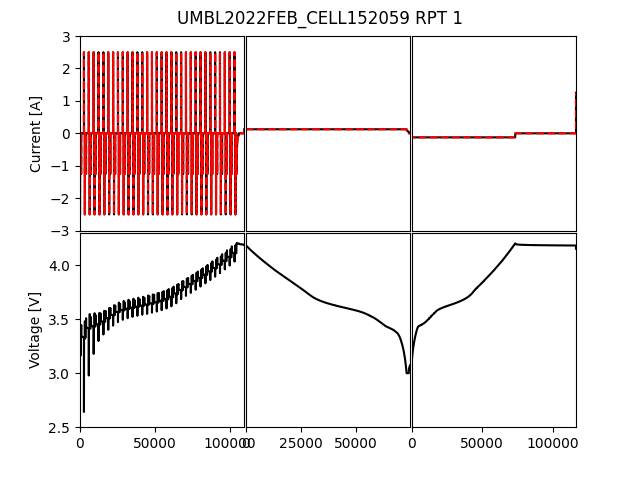

In [10]:
# plot subcycle data 

fig,axs = plt.subplots(2,3)
plt.subplots_adjust(wspace = 0.01,hspace = 0.01, top = 0.925)
current_profiles=[]
# index, row in df.iterrows()
for s,(index,subcycle) in enumerate(rpt_data.iterrows()): #[hppc, charge, discharge]
    subcycle_data = subcycle.Data
    t_data = subcycle_data["Time [ms]"].to_numpy()/1000
    t_data=t_data-t_data[0]
    I_data = -subcycle_data['Current [A]'].to_numpy() # pybamm I>0 on discharge 
    # I_data = np.interp(t_sim, t_data, I_data, left=None, right=None, period=None)
    V_data= subcycle_data['Voltage [V]'].to_numpy()
    # V_data = np.interp(t_sim, t_data, V_data, left=None, right=None, period=None)

    # save current profile for running sim
    df0 = pd.DataFrame({'t':t_data, 'I':I_data})
    df = df0.drop_duplicates(subset='t', keep="last")
    current_profile = df.to_numpy() #.iloc[0:3200]
    current_profiles.append(current_profile)

    # plot current
    ax = axs[0,s]
    ax.plot(t_data,I_data,'k')
    ax.plot(current_profile[:,0],current_profile[:,1],'r--')
    ax.set_xlim(left=0, right = t_data[-1])
    ax.set_xlabel('Time [s]')
    ax.set_ylim([-3,3])
    if s ==0:
        ax.set_ylabel('Current [A]') 
    else: 
        ax.set_yticks([])
        ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_xticklabels([])

    #plot voltage
    ax = axs[1,s]
    ax.plot(t_data,V_data,'k')
    ax.set_xlim(left=0, right = t_data[-1])
    ax.set_ylim([2.5,4.3])
    if s ==0:
        ax.set_ylabel('Voltage [V]')
    else: 
        ax.set_yticks([])
        ax.set_yticklabels([])

    
fig.suptitle(f'{cell_name} RPT {rpt_num}')


## Simulation set up 

In [30]:
# update model parameters 
parameters =  pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Tran2025)
model = pybamm.lithium_ion.SPMe(
    {# "SEI": "ec reaction limited",
    }
) # originally spme?

parameters.update(
    {
        "Maximum concentration in positive electrode [mol.m-3]": 31927.3,
        "Maximum concentration in negative electrode [mol.m-3]": 29637,
        "Upper voltage cut-off [V]": 4.25, 
        "Lower voltage cut-off [V]": 2.5, 
        },
    check_already_exists=False,
)    
# Calculate initial SOC
I_ocv = charge.Data['Current [A]']
t_ocv = charge.Data.loc[I_ocv>0,'Time [ms]']/1000
SOC_ocv = (integrate.cumulative_trapezoid(I_ocv[I_ocv>0],t_ocv/3600,initial=0))/charge['Charge capacity [A.h]']
V_ocv = charge.Data.loc[I_ocv>0,'Voltage [V]']
try: 
        Cn = charge.Cn
        Cp =charge.Cp
        x100 = charge.x100
        x0 = charge.x0
        y100=charge.y100
        y0=charge.y0
except: 
        # if any(np.isnan([Cn, Cp, x100, x0, y100,y0])):
        C_n_init = 4.06-1
        C_p_init =5.5-1
        x_init = 0.852
        y_init = 0.309
        Cn, Cp, x100, x0, y100, y0 = calculate_eSOH(C_n_init, C_p_init, x_init, y_init,model, parameters)
    
# set initial concentrations from SOC using OCV from C/20 discharge
parameter_sets=[]
for index,subcycle in rpt_data.iterrows():
    subcycle_data = subcycle.Data
    parameter_set = parameters.copy()
    V_0 = subcycle_data['Voltage [V]'].iloc[0]
    SOC_0 = np.interp(V_0, V_ocv, SOC_ocv) # V_ocv needs to be increasing

    x_init = (x100-x0)*SOC_0 + x0 
    y_init = (y100-y0)*SOC_0 + y0 

    param = model.param
    eps_n_init = parameter_set.evaluate(Cn*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
    eps_p_init = parameter_set.evaluate(Cp*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
    cs_n_init = parameter_set.evaluate(x_init* param.n.prim.c_max)
    cs_p_init = parameter_set.evaluate(y_init* param.p.prim.c_max)

    # Updating parameters for initialization
    parameter_set.update(
        {
            "Negative electrode active material volume fraction": eps_n_init,
            "Positive electrode active material volume fraction": eps_p_init,
            "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
            "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
            "Initial temperature [K]": 273.15+25,
            "Ambient temperature [K]": 273.15+25,
        },
        check_already_exists=False,
    )
    parameter_sets.append(parameter_set)
    print(f"SOC_0: {SOC_0}") 
print(f"x0: {x0}") 
print(f"x100: {x100}") 
print(f"y0: {y0}") 
print(f"y100: {y100}") 
print(f"Cn (usable): {(x100-x0)*Cn}") 
print(f"Cp (usable): {(y0-y100)*Cp}") 


SOC_0: 0.0027892452028489543
SOC_0: 0.99210301054985
SOC_0: 0.0
x0: 0.0198
x100: 0.8359
y0: 0.9465
y100: 0.3052
Cn (usable): 2.5514550399999996
Cp (usable): 2.55160444


In [25]:
# create experiments corresponding to rpt subcycle order
experiments=[]
for current_profile in current_profiles: #[hppc, charge, discharge]
    experiment = pybamm.Experiment(
            ["Rest for 1 second", 
            "Run current_profile (A)",
            ],
            drive_cycles={
                'current_profile': current_profile
            }, period = "1 second"
        )
    experiments.append(experiment)

In [26]:
# simulate subcycles
sols=[]
for i,(experiment, parameter_set) in enumerate(zip(experiments, parameter_sets)):
    print(i)
    sim = pybamm.Simulation(model, experiment=experiment,
                            parameter_values=parameter_set, 
                            solver=pybamm.CasadiSolver("safe"))
    sols.append(sim.solve()) #initial_soc=SOC_0

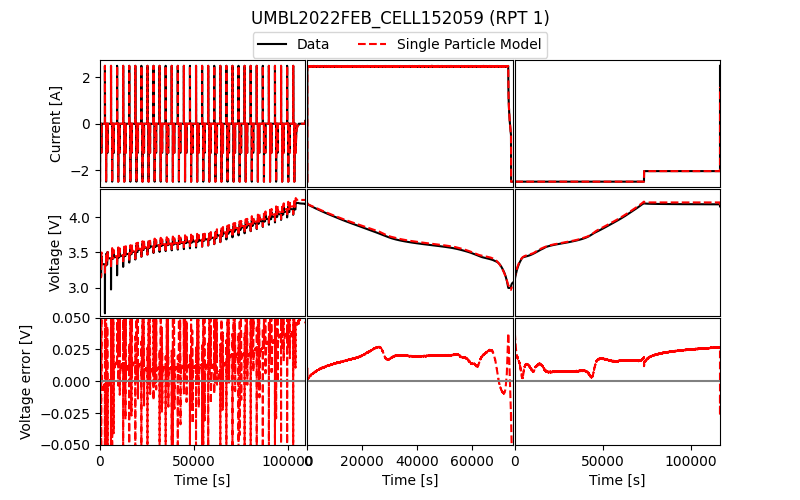

In [12]:
# plot data and sim results 
fig,axs = plt.subplots(3,len(sols),figsize=(8,5))
plt.subplots_adjust(hspace=0.01, wspace=0.01)
for s,(sol,(index,subcycle)) in enumerate(zip(sols, rpt_data.iterrows())):
    subcycle_data = subcycle.Data
    t_data = (subcycle_data['Time [ms]']-subcycle_data['Time [ms]'].iloc[0])/1000
    I_data = -subcycle_data['Current [A]']
    V_data = subcycle_data['Voltage [V]']
    t = sol["Time [s]"].entries
    I = sol["Current [A]"].entries
    Q = sol['Discharge capacity [A.h]'].entries
    Vt = sol["Terminal voltage [V]"].entries

    # plt.subplots_adjust(left=0.12, bottom=0.12, right=0.99, top=0.90) #, wspace=0.5, hspace=0.1

    ax = axs[0,s]
    ax.plot(t_data,I_data,'k', label = 'Data')
    ax.plot(t,I,'r--',  label = model.name)
    ax.set_xlim([0,t_data.iloc[-1]])
    if s ==0:
        ax.set_ylabel('Current [A]')
    else: 
        ax.set_yticks([])
        ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_xticklabels([])

    ax = axs[1,s]
    e_V = Vt - np.interp(t,t_data, V_data)
    rmse_v = np.sqrt(np.mean(e_V**2))
    ax.plot(t_data,V_data,'k', label = 'Data')
    ax.plot(t,Vt,'r--',  label = model.name + f' (RMSE = {round(rmse_v*1000)} mV)')
    ax.set_xlim([0,t_data.iloc[-1]])
    ax.set_ylim([2.6,4.4])
    if s ==0:
        ax.set_ylabel('Voltage [V]')
    else: 
        ax.set_yticks([])
        ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_xticklabels([])

    ax = axs[2,s]
    ax.plot(t,e_V,'r--')
    xlims = ax.get_xlim()
    ax.plot(xlims, [0]*2, 'grey')
    ax.set_xlim([0,t_data.iloc[-1]])
    ax.set_ylim([-0.05,0.05])
    if s ==0:
        ax.set_ylabel('Voltage error [V]')
    else: 
        ax.set_yticks([])
        ax.set_yticklabels([])
    # ax.set_xticks([])
    # ax.set_xticklabels([])
    ax.set_xlabel('Time [s]')


# fig.tight_layout()
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center', ncol = 2, bbox_to_anchor=(0.5, .91), fancybox=True) #prop={'size': 10},  
fig.suptitle(cell_name + f' (RPT {rpt_num})')
plt.savefig('./figs/' + cell_name + '.jpg',format='jpg',dpi=300)

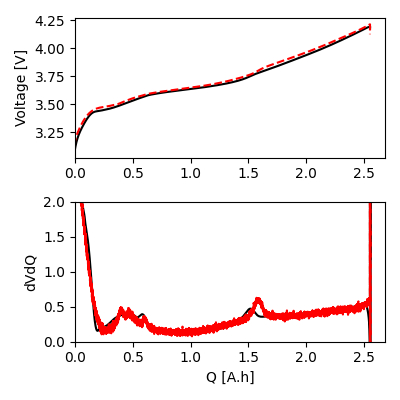

In [ ]:
# filter, calculate, and plot dQdV from data and sim results 
if np.mean(I_data)<0: # charge
    Ah_sim=integrate.cumtrapz(-I,t,initial=0)/3600
    Ah_data=integrate.cumtrapz(-I_data,t_data,initial=0)/3600
else:# discharge
    Ah_sim=integrate.cumtrapz(I,t,initial=0)/3600
    Ah_data=integrate.cumtrapz(I_data,t_data,initial=0)/3600


# sgolay filter data and calculate dVdQ
window_length=501
polyorder=5
Qf_d = savgol_filter(Ah_data,window_length,polyorder)
dQ_d = savgol_filter(Ah_data,window_length,polyorder,1)
Vf_d = savgol_filter(V_data,window_length,polyorder)
dV_d = savgol_filter(V_data,window_length,polyorder,1)
dVdQ_d = dV_d/dQ_d

# sgolay filter sim results and calculate dVdQ
window_length=51
polyorder=5
Qf_s = savgol_filter(Ah_sim,window_length,polyorder)
dQ_s = savgol_filter(Ah_sim,window_length,polyorder,1)
Vf_s = savgol_filter(Vt,window_length,polyorder)
dV_s = savgol_filter(Vt,window_length,polyorder,1)
dVdQ_s = dV_s/dQ_s

# plot data vs sim dVdQ
fig,ax = plt.subplots(2,1,figsize=(4,4))
ax1 = ax.flat[0]
ax1.plot(Qf_d,Vf_d,'k')
ax1.plot(Qf_s,Vf_s,'r--')
ax1.set_xlim(left=0)

ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(Qf_d,dVdQ_d,'k')
ax2.plot(Qf_s,dVdQ_s,'r--')
ax2.set_xlim(left=0)
# ax2.set_ylim([-2,2])
ax2.set_ylim([0,2])
ax2.set_xlabel('Q [A.h]')
ax2.set_ylabel('dVdQ')
fig.tight_layout()

plt.savefig('./figs/' + cell_name + '_dqdv.jpg',format='jpg',dpi=300)


# Archive

In [ ]:
param_dict = Siegel2022.get_parameter_values()
parameters_js = param_dict #pybamm.ParameterValues(param_dict)  
parameters =  pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)

keys = parameters_js.keys()
keys_mismatch = []
keys_match = []
keys_dne = []
for key in keys: 
    try:
        if parameters[key] != parameters_js[key]:
            if isinstance(parameters[key],(int, float)): # ignore functions and drive cycle
                keys_mismatch.append(key)
        else:
            keys_match.append(key)
    except:
        keys_dne.append(key)

# df = pd.DataFrame([parameters[k for k in keys_mismatch], parameters_js[k for k in keys_mismatch]])
# [parameters[k] for k in keys_mismatch]
df = pd.DataFrame([{k: parameters[k] for k in keys_mismatch},
                   {k: parameters_js[k] for k in keys_mismatch}]
                   )
# df["Name"] = ["Sravan's", "Jason's"]
df.insert(0, "Name", ["Sravan's", "Jason's"])
df

,Name,Exchange-current density for plating [A.m-2],Lithium plating transfer coefficient,Initial outer SEI thickness [m],SEI growth activation energy [J.mol-1],Negative current collector thickness [m],Positive current collector thickness [m],Current function [A],Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5],Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5],Separator porosity,Upper voltage cut-off [V]
0,Sravan's,0.001,0.70,2.500000e-09,0.0,0.000010,0.000015,3.0,0.000001,4.824000e-06,0.48,4.2
1,Jason's,<function plating_exchange_current_density_OKa...,0.65,2.550000e-09,38000.0,0.000005,0.000008,3.5,0.000001,1.371554e-07,0.30,4.3


0.0064743913298232975


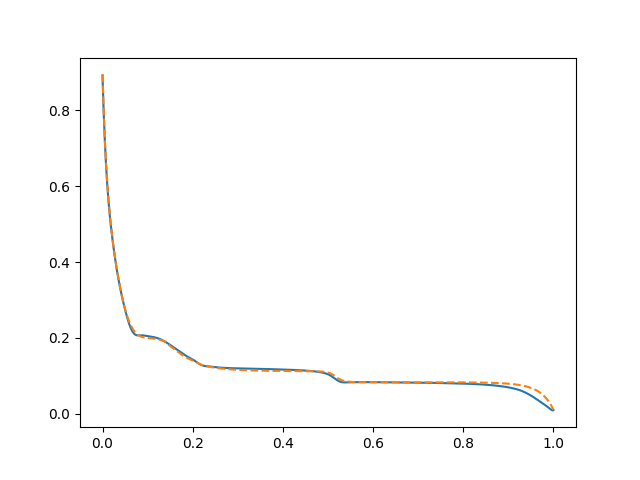

In [ ]:
# plot Un fit
fn = r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm\input\parameters\lithium_ion\negative_electrodes\graphite_UMBL_Tran2025\graphite_ocp_Siegel.csv' 
Un_data = pd.read_csv(fn, comment='#', header = None, names = ["x", "Un"])
sto = Un_data.x+0.002 #<-----EDIT


# var=[-3.54049607669295,0.00708244334002580,0.00774192469266890, 
# 4.26893363759502,-0.0164043013936254,-4.05401806281007, 
# 0.0426131798578846,-3.19444157210193,0.0503611972394406, 
# 0.170261138869476,0.147567301186300,0.0382504766072001, 
# 0.519446050169237,1.10619736534131,0.0145120887836752, 
# -0.0816693980616928,-0.0119716740325398,-0.00723858739498425, 
# -0.0877677643234304,0.0238786887373114,0.0452264234816890, 
# -0.00713413913218840]

p_eq=[-3.54049607669295,0.00708244334002580,0.00774192469266890, 
    4.26893363759502,-0.0164043013936254,-4.05401806281007, 
    0.0426131798578846,-3.19444157210193]#var[0:8]
a_eq=[0.0503611972394406, 0.170261138869476,0.147567301186300,
    0.0382504766072001, 0.519446050169237,1.10619736534131,
    0.0145120887836752,]#var[8:15]
b_eq = [-0.0816693980616928,-0.0119716740325398,-0.00723858739498425, 
    -0.0877677643234304,0.0238786887373114,0.0452264234816890, 
    -0.00713413913218840]#var[15:]
u_eq2=p_eq[-1]+p_eq[-2]*np.exp((sto-a_eq[-1])/b_eq[-1])
for i in range(6):
    u_eq2 += p_eq[i]*np.tanh((sto-a_eq[i])/b_eq[i])

# var = [-2.74740857138957,0.00443109156371119,0.0140962302368559, 
#     3.10348817994589,-0.0128948359572101,-4.36083705035769, 
#     0.0643328570911640,-3.88703879262989,0.0631828141079049, 
#     0.213012646348329,0.174731100372283,0.0577291579271751, 
#     0.518982409471130,1.21588542781399,0.0150389780167150, 
#     -0.0584524226380269,-0.00702394962468186,-0.0342305292048576, 
#     -0.0619846453717142,0.0123530018211038,0.0873816814557679, 
#     -0.00843321991754559]
p_eq=[-2.74740857138957,0.00443109156371119,0.0140962302368559, 
    3.10348817994589,-0.0128948359572101,-4.36083705035769, 
    0.0643328570911640,-3.88703879262989]#var[0:8]
a_eq=[0.0631828141079049,
    0.213012646348329,0.174731100372283,0.0577291579271751, 
    0.518982409471130,1.21588542781399,0.0150389780167150]#var[8:15]
b_eq = [-0.0584524226380269,-0.00702394962468186,-0.0342305292048576, 
    -0.0619846453717142,0.0123530018211038,0.0873816814557679, 
    -0.00843321991754559] #var[15:]
u_eq1=p_eq[-1]+p_eq[-2]*np.exp((sto-a_eq[-1])/b_eq[-1])
for i in range(6):
    u_eq1 += p_eq[i]*np.tanh((sto-a_eq[i])/b_eq[i])

Un_fit = (u_eq1 + u_eq2)/2-0.01 #<-----EDIT

# calculate rmse (0.0167 NOMINAL)
rmse_Un = np.sqrt(np.mean((Un_fit-Un_data.Un)**2))
print(rmse_Un)

# plot
plt.close('all')
plt.plot(Un_data.x, Un_data.Un)
plt.plot(Un_data.x, Un_fit, '--')
# plt.plot(Up_data.y, Up_fit2)
plt.show()

0.010355647169182273


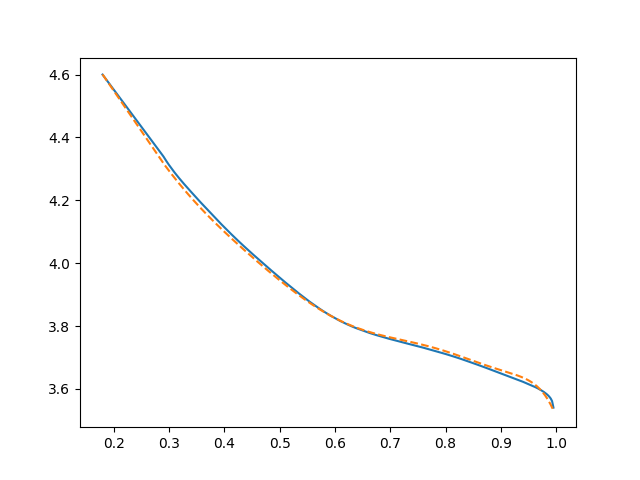

In [ ]:
# plot Up fit
fn = r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm\input\parameters\lithium_ion\positive_electrodes\NMC_UMBL_Tran2025\NMC_ocp_Siegel.csv' 
Up_data = pd.read_csv(fn, comment='#', header = None, names = ["y", "Up"]).iloc[0:-1]


p1 = -2253.9364
p2 = 10756.6071
p3 = -21755.8183
p4 = 24277.2504
p5 = -16299.5659
p6 = 6728.9153
p7 = -1670.2785
p8 = 233.2321
p9 = -18.3223*0.9979 #<-----EDIT
p10 = 5.3936*0.999 #<-----EDIT

sto = Up_data.y
Up_fit = p1*sto**9 + p2*sto**8 + p3*sto**7 + p4*sto**6 + p5*sto**5 + p6*sto**4 + p7*sto**3 + p8*sto**2 + p9*sto + p10

# calculate rmse (0.0215 NOMINAL)
rmse_Up = np.sqrt(np.mean((Up_fit-Up_data.Up)**2))
print(rmse_Up)

plt.close('all')
plt.plot(Up_data.y, Up_data.Up)
plt.plot(Up_data.y, Up_fit,'--')
# plt.plot(Up_data.y, Up_fit2)
plt.show()

4.19395542
1.0


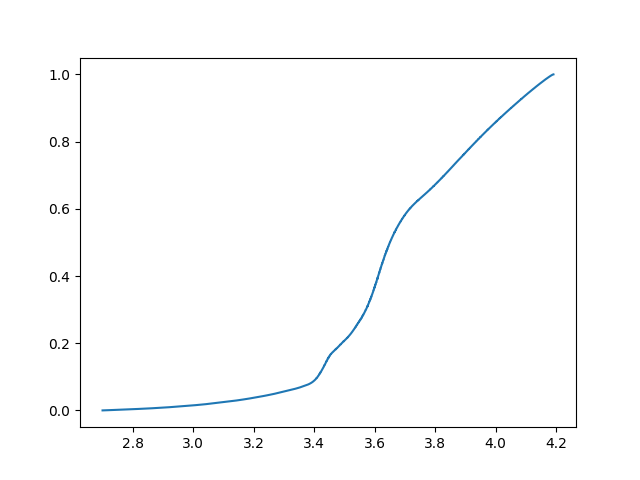

In [ ]:
I_d = abs(discharge.Data['Current [A]'])
t_d = discharge.Data.loc[I_d>0,'Time [ms]']/1000
V_ocv = discharge.Data.loc[I_d>0,'Voltage [V]']
SOC_ocv = (discharge['Discharge capacity [A.h]']-integrate.cumtrapz(I_d[I_d>0],t_d/3600,initial=0))/discharge['Discharge capacity [A.h]']
V_0 = subcycle_data['Voltage [V]'].iloc[0]
SOC_0 = np.interp(4.2, V_ocv[::-1], SOC_ocv[::-1]) # V_ocv needs to be increasing
print(V_0)
print(SOC_0)
plt.close('all')
plt.plot(V_ocv,SOC_ocv)
plt.show()

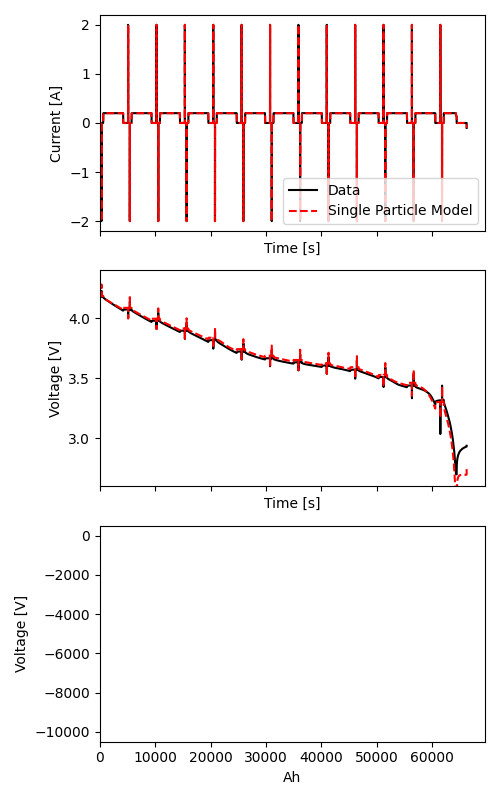

In [ ]:
# plot data and sim results 
t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
Q = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries
if np.mean(I_data)<0:
    Ah_data=integrate.cumtrapz(-I_data,t_data,initial=0)/3600
    Ah_sim=integrate.cumtrapz(-I,t,initial=0)/3600
else:
    Ah_data=integrate.cumtrapz(I_data,t_data,initial=0)/3600
    Ah_sim=integrate.cumtrapz(I,t,initial=0)/3600


fig,axs = plt.subplots(3,1,figsize=(5,8))#,sharex=True)
axs = axs.flatten()
ax = axs[0]
ax.plot(t_data,I_data,'k', label = 'Data')
ax.plot(t,I,'r--',  label = model.name)
ax.legend()
ax.set_xlim(left=0)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Current [A]')


ax = axs[1]
ax.plot(t_data,V_data,'k')
ax.plot(t,Vt,'r--')
ax.set_xlim(left=0)
ax.set_ylim([2.6,4.4])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')


ax = axs[2]
ax.plot(Ah_data,V_data,'k')
ax.plot(Ah_sim,Vt,'r--')
ax.set_xlim(left=0)
ax.set_xlabel('Ah')
ax.set_ylabel('Voltage [V]')
fig.tight_layout()

